# Data Prepration and Cleaning for Ml Model Building

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_excel('Test.xlsx')
df.head()

,customer_id,order_id,order_item_id,product_id,customer_tenure_days,membership_type,lifetime_spend,total_orders,total_returns,return_rate,...,item_condition,missing_tags,worn_signs,scratches,stains,packaging_damage,complaint_count,average_resolution_time,sentiment,fraud_label
0,CUST00041,ORDV3000001,ITEMV3000001,PROD06855,969,Gold,52411.53,58,14,0.241,...,Poor,No,Yes,Yes,Yes,No,1.0,61.8,Negative,0
1,CUST16311,ORDV3000002,ITEMV3000002,PROD06691,2327,Platinum,37460.18,120,20,0.167,...,Poor,No,No,Yes,Yes,Yes,7.0,28.4,Positive,0
2,CUST01353,ORDV3000003,ITEMV3000003,PROD00091,1776,Silver,11499.08,21,8,0.381,...,Good,Yes,Yes,No,No,No,8.0,49.3,Negative,1
3,CUST17397,ORDV3000004,ITEMV3000004,PROD07999,864,Silver,80132.54,109,54,0.495,...,Poor,No,No,No,No,No,3.0,11.0,Neutral,1
4,CUST16220,ORDV3000005,ITEMV3000005,PROD01157,1546,Silver,79857.25,110,49,0.445,...,Poor,No,No,No,Yes,No,0.0,49.8,Neutral,0


In [3]:
df.shape

(50000, 39)

In [4]:
df.columns

Index(['customer_id', 'order_id', 'order_item_id', 'product_id',
       'customer_tenure_days', 'membership_type', 'lifetime_spend',
       'total_orders', 'total_returns', 'return_rate', 'average_order_value',
       'purchase_frequency', 'category', 'brand', 'selling_price',
       'luxury_flag', 'order_date', 'delivery_date', 'delivery_delay',
       'quantity', 'order_amount', 'discount', 'coupon_used', 'payment_method',
       'return_date', 'return_days', 'return_reason', 'refund_amount',
       'previous_return_reason', 'item_condition', 'missing_tags',
       'worn_signs', 'scratches', 'stains', 'packaging_damage',
       'complaint_count', 'average_resolution_time', 'sentiment',
       'fraud_label'],
      dtype='object')

## 3. Data Cleaning and Preprocessing

### 3.1 Checking Datatypes

In [5]:
df.dtypes

customer_id                 object
order_id                    object
order_item_id               object
product_id                  object
customer_tenure_days         int64
membership_type             object
lifetime_spend             float64
total_orders                 int64
total_returns                int64
return_rate                float64
average_order_value        float64
purchase_frequency         float64
category                    object
brand                       object
selling_price              float64
luxury_flag                 object
order_date                  object
delivery_date               object
delivery_delay             float64
quantity                     int64
order_amount               float64
discount                   float64
coupon_used                 object
payment_method              object
return_date                 object
return_days                  int64
return_reason               object
refund_amount              float64
previous_return_reas

### 3.2 Converting Datatype of Date related Columns

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df['return_date'] = pd.to_datetime(df['return_date'])

### 3.3 Checking Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

### 3.4 Handling Missing Values

In [8]:
def count_per_null(data):
    nv = data.isnull().sum()    
    nv = nv[nv>0]
    nv_df = pd.DataFrame({'Feature':nv.index,'Null_Count':nv.values,
                         'Null%':(nv.values/data.shape[0])*100})
    nv_df = nv_df.sort_values('Null%',ascending=False)
    return nv_df

In [9]:
count_per_null(df)

,Feature,Null_Count,Null%
10,previous_return_reason,3954,7.908
15,sentiment,1625,3.250
8,return_reason,1490,2.980
6,coupon_used,1008,2.016
4,delivery_delay,975,1.950
14,average_resolution_time,958,1.916
11,item_condition,947,1.894
7,payment_method,550,1.100
0,membership_type,532,1.064
5,discount,516,1.032


In [10]:
df.dropna(subset=['lifetime_spend','brand','missing_tags',
                   'refund_amount','complaint_count','category'],inplace=True)

In [11]:
df.dtypes

customer_id                        object
order_id                           object
order_item_id                      object
product_id                         object
customer_tenure_days                int64
membership_type                    object
lifetime_spend                    float64
total_orders                        int64
total_returns                       int64
return_rate                       float64
average_order_value               float64
purchase_frequency                float64
category                           object
brand                              object
selling_price                     float64
luxury_flag                        object
order_date                 datetime64[ns]
delivery_date              datetime64[ns]
delivery_delay                    float64
quantity                            int64
order_amount                      float64
discount                          float64
coupon_used                        object
payment_method                    

In [12]:
df['previous_return_reason'].value_counts()

previous_return_reason
Wrong Item       7410
Late Delivery    7331
Damaged          7308
Changed Mind     7278
Defective        7250
Wrong Size       7198
Name: count, dtype: int64

In [13]:
df['previous_return_reason'] = df['previous_return_reason'].fillna(df.groupby('customer_id')
    ['previous_return_reason'].transform(lambda x:x.mode().iloc[0] if not x.mode().empty else np.nan))

In [14]:
df['previous_return_reason'].value_counts()

previous_return_reason
Changed Mind     8197
Damaged          8002
Defective        7846
Wrong Item       7810
Late Delivery    7775
Wrong Size       7492
Name: count, dtype: int64

In [15]:
def value_count(data):
    vc = data.value_counts()
    vc_df = pd.DataFrame({'Feature':vc.index,'count':vc.values,'values%':((vc.values/vc.values.sum()))})
    return vc_df

In [16]:
value_count(df['previous_return_reason'])

,Feature,count,values%
0,Changed Mind,8197,0.173953
1,Damaged,8002,0.169815
2,Defective,7846,0.166504
3,Wrong Item,7810,0.165740
4,Late Delivery,7775,0.164997
5,Wrong Size,7492,0.158992


In [17]:
reasons = ['Changed Mind','Damaged','Defective','Wrong Item','Late Delivery','Wrong delivery']
mask = df['previous_return_reason'].isna()
df.loc[mask,'previous_return_reason'] = np.random.choice(reasons,size=mask.sum(),
    p=[0.17, 0.16, 0.24, 0.15, 0.14, 0.14])

In [18]:
count_per_null(df)

,Feature,Null_Count,Null%
8,sentiment,1546,3.251656
5,return_reason,1424,2.995057
3,coupon_used,961,2.021243
1,delivery_delay,918,1.930802
7,average_resolution_time,916,1.926596
6,item_condition,895,1.882427
4,payment_method,529,1.112630
0,membership_type,510,1.072668
2,discount,491,1.032706


In [19]:
df['sentiment'].value_counts()

sentiment
Positive    15434
Neutral     15291
Negative    15274
Name: count, dtype: int64

In [20]:
value_count(df['sentiment'])

,Feature,count,values%
0,Positive,15434,0.335529
1,Neutral,15291,0.332420
2,Negative,15274,0.332051


In [21]:
def fill_random_choice(df,columns,choices,probabilities):
    mask = df[columns].isna()
    df.loc[mask,columns] = np.random.choice(choices,
                                           size=mask.sum(),
                                           p=probabilities)

In [22]:
reasons1 = ['Positive','Neutral','Negative']
probs = [0.33,0.33,0.34]
fill_random_choice(df,'sentiment',reasons1,probs)

In [23]:
value_count(df['return_reason'])

,Feature,count,values%
0,Wrong Item,7766,0.168383
1,Late Delivery,7740,0.167819
2,Changed Mind,7704,0.167039
3,Wrong Size,7683,0.166584
4,Defective,7623,0.165283
5,Damaged,7605,0.164892


In [24]:
reasons2 = ['Wrong Item','Late Delivery','Changed Mind','Wrong Size','Defective','Damaged']
probs2 = [0.17,0.17,0.17,0.17,0.16,0.16]
fill_random_choice(df,'return_reason',reasons2,probs2)

In [25]:
value_count(df['coupon_used'])

,Feature,count,values%
0,Yes,23332,0.500859
1,No,23252,0.499141


In [26]:
reasons3 = ['Yes','No']
probs3 = [0.5,0.5]
fill_random_choice(df,'coupon_used',reasons3,probs3)

In [27]:
value_count(df['delivery_delay'])

,Feature,count,values%
0,4.0,4753,0.101937
1,5.0,4720,0.101229
2,3.0,4706,0.100929
3,8.0,4685,0.100478
4,10.0,4648,0.099685
5,7.0,4637,0.099449
6,6.0,4633,0.099363
7,2.0,4633,0.099363
8,9.0,4617,0.099020
9,1.0,4595,0.098548


In [28]:
reasons4 = [4.0,5.0,3.0,8.0,10.0,7.0,6.0,2.0,9.0,1.0]
probs4 = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]
fill_random_choice(df,'delivery_delay',reasons4,probs4)

In [29]:
value_count(df['item_condition'])

,Feature,count,values%
0,Poor,11788,0.252690
1,Excellent,11773,0.252369
2,Good,11576,0.248146
3,Fair,11513,0.246795


In [30]:
reasons5 = ['Poor','Excellent','Good','Fair']
probs5 = [0.25,0.25,0.25,0.25]
fill_random_choice(df,'item_condition',reasons5,probs5)

In [31]:
value_count(df['payment_method'])

,Feature,count,values%
0,Wallet,9504,0.202144
1,COD,9418,0.200315
2,Card,9385,0.199613
3,UPI,9360,0.199081
4,NetBanking,9349,0.198847


In [32]:
reasons5 = ['Wallet','COD','Card','UPI','Netbanking']
probs5 = [0.20,0.20,0.20,0.20,0.20]
fill_random_choice(df,'payment_method',reasons5,probs5)

In [33]:
value_count(df['membership_type'])

,Feature,count,values%
0,Silver,11831,0.251536
1,Platinum,11781,0.250473
2,Gold,11753,0.249878
3,Basic,11670,0.248113


In [34]:
reasons6 = ['Silver','Platinum','Gold','Basic']
probs6 = [0.25,0.25,0.25,0.25]
fill_random_choice(df,'membership_type',reasons6,probs6)

In [35]:
value_count(df['discount'])

,Feature,count,values%
0,15.0,6839,0.145344
1,10.0,6818,0.144897
2,30.0,6748,0.143410
3,20.0,6741,0.143261
4,40.0,6688,0.142135
5,0.0,6678,0.141922
6,5.0,6542,0.139032


In [36]:
reasons7 = [15.0,10.0,30.0,20.0,40.0,0.0,5.0]
probs7 = [0.15,0.15,0.14,0.14,0.14,0.14, 0.14]
fill_random_choice(df,'discount',reasons7,probs7)

In [37]:
df['average_resolution_time'] = df['average_resolution_time'].fillna(df['average_resolution_time'].median())

In [38]:
count_per_null(df)

,Feature,Null_Count,Null%


## 4. Exploratory Data Analysis(EDA)

### 4.1 Seperating Categorical and Numerical Features

In [39]:
cat_cols = df.dtypes[df.dtypes==object].index
num_cols = df.select_dtypes(include=['number']).columns
print(cat_cols)
print(len(cat_cols))
print(num_cols)

Index(['customer_id', 'order_id', 'order_item_id', 'product_id',
       'membership_type', 'category', 'brand', 'luxury_flag', 'coupon_used',
       'payment_method', 'return_reason', 'previous_return_reason',
       'item_condition', 'missing_tags', 'worn_signs', 'scratches', 'stains',
       'packaging_damage', 'sentiment'],
      dtype='object')
19
Index(['customer_tenure_days', 'lifetime_spend', 'total_orders',
       'total_returns', 'return_rate', 'average_order_value',
       'purchase_frequency', 'selling_price', 'delivery_delay', 'quantity',
       'order_amount', 'discount', 'return_days', 'refund_amount',
       'complaint_count', 'average_resolution_time', 'fraud_label'],
      dtype='object')


In [40]:
for i in cat_cols[3:]:
    df[i] = df[i].str.lower().str.strip()

### 4.2 Univariate Numerical KDE Plot

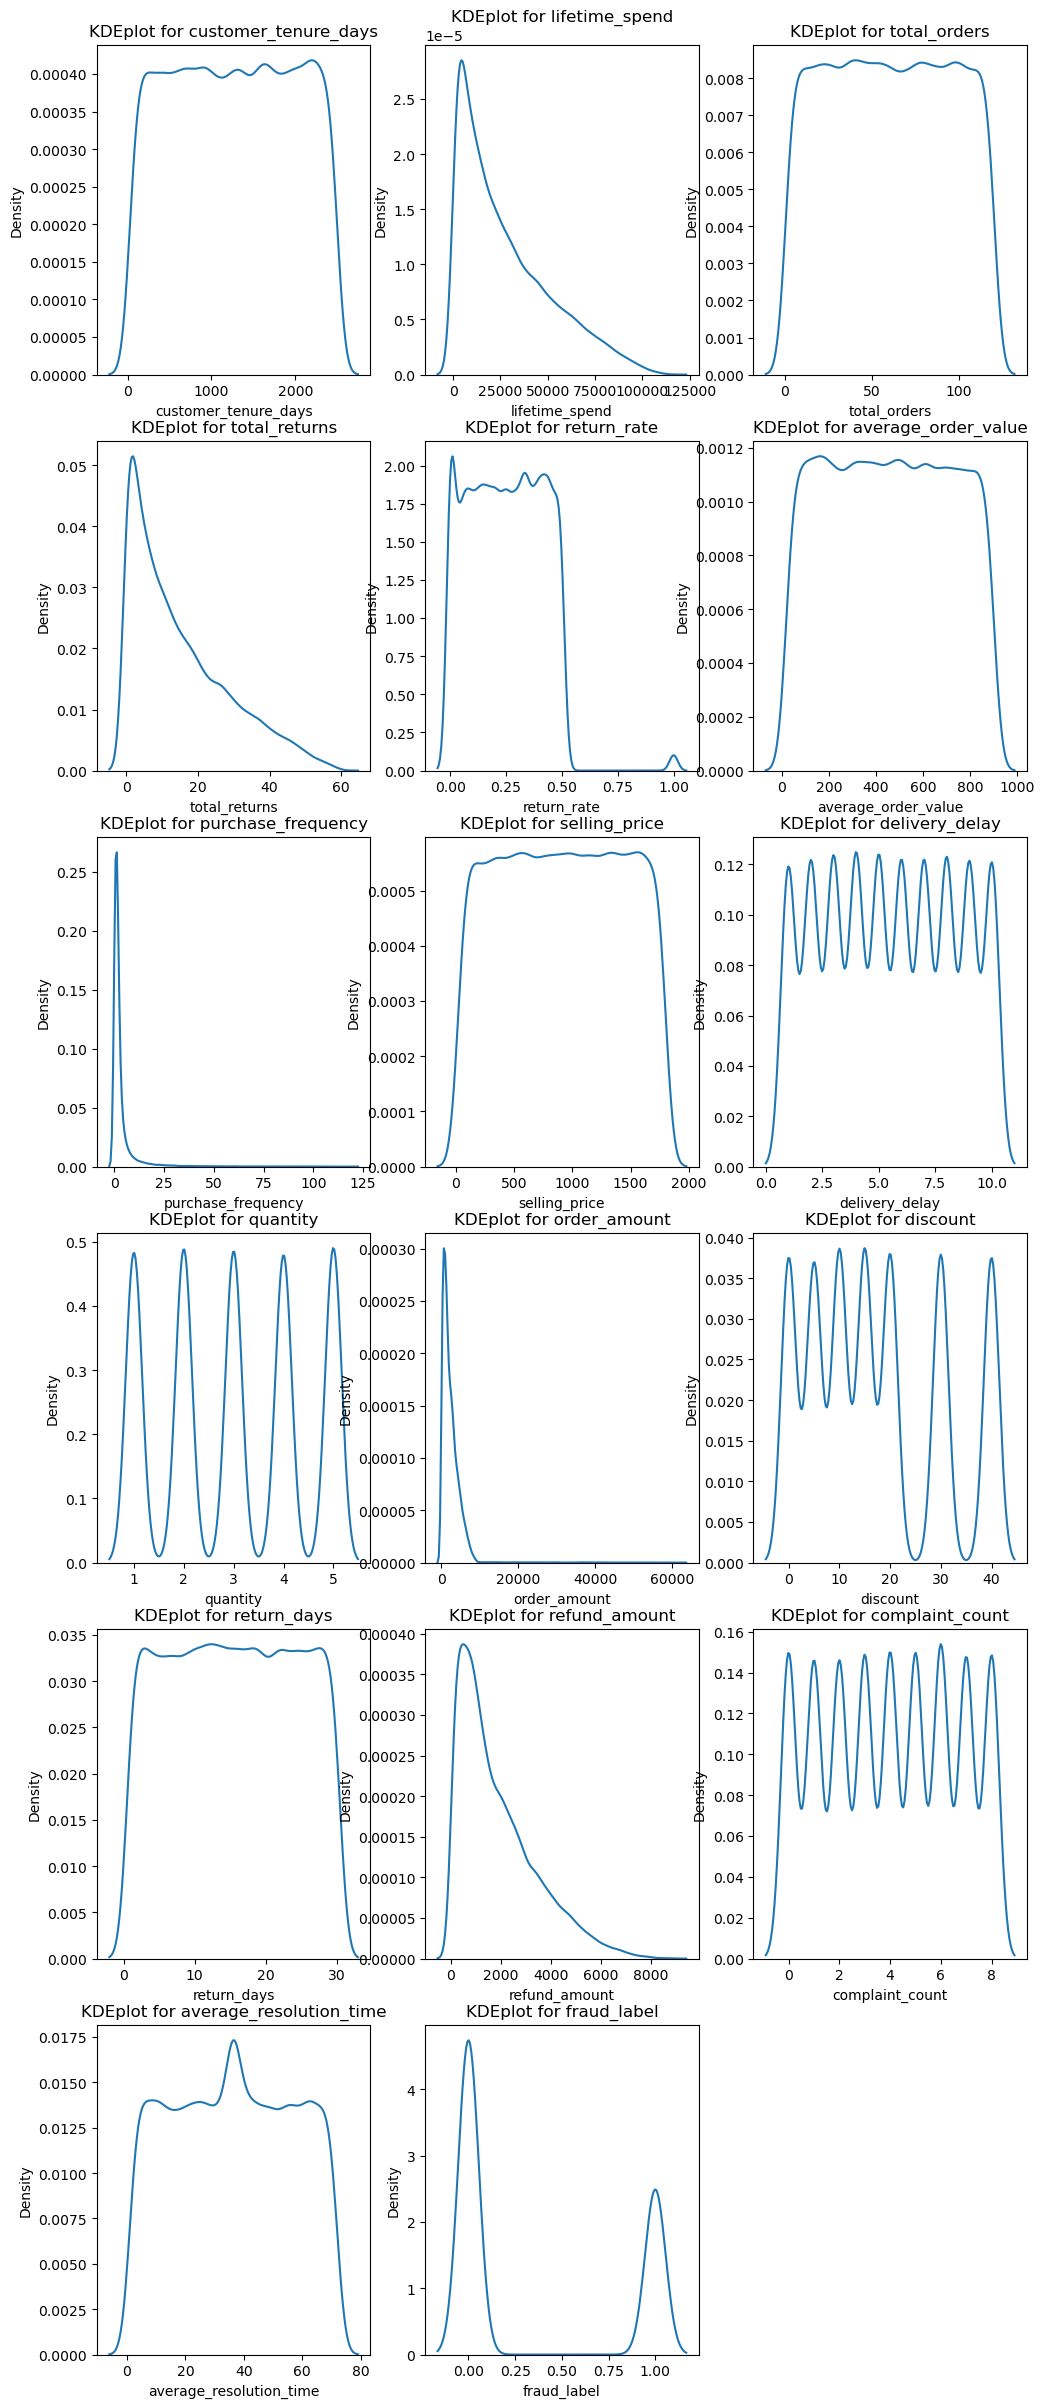

In [41]:
cols = num_cols
plt.figure(figsize=(12,30)) 
for i in range(len(cols)):
    plt.subplot(6,3,i+1) 
    sns.kdeplot(data=df,x=cols[i])
    plt.title(f'KDEplot for {cols[i]}')
plt.show()

## 5. Outlier Treatment

In [42]:
a = df[num_cols].describe(percentiles=[0.01,0.02,0.05,0.95,0.97,0.98,0.99]).T
a = a.iloc[:,3:]
a

,min,1%,2%,5%,50%,95%,97%,98%,99%,max
customer_tenure_days,30.00,55.0000,79.0000,153.200,1271.00,2374.000,2424.0000,2448.0000,2474.0000,2500.00
lifetime_spend,26.11,383.0068,652.6428,1485.430,20850.29,76425.346,83092.4128,87581.5432,93809.1180,114922.96
total_orders,1.00,2.0000,3.0000,7.000,60.00,114.000,117.0000,118.0000,119.0000,120.00
total_returns,0.00,0.0000,0.0000,0.000,11.00,42.000,46.0000,49.0000,52.0000,60.00
return_rate,0.00,0.0000,0.0000,0.000,0.25,0.487,0.5000,0.5000,0.5000,1.00
average_order_value,20.02,28.3632,36.3600,63.652,457.39,855.308,873.5468,883.1524,891.6000,900.00
purchase_frequency,0.01,0.0400,0.0700,0.150,1.43,11.996,17.7300,23.5736,35.4780,120.00
selling_price,20.07,38.4664,56.3820,111.038,914.56,1711.108,1745.9304,1764.0772,1782.4148,1799.91
delivery_delay,1.00,1.0000,1.0000,1.000,5.00,10.000,10.0000,10.0000,10.0000,10.00
quantity,1.00,1.0000,1.0000,1.000,3.00,5.000,5.0000,5.0000,5.0000,5.00


In [43]:
print((df['purchase_frequency']>=35.4780).sum()) #1%

476


In [44]:
cols1 = ['purchase_frequency','order_amount']
for i in cols1:
    upper = df[i].quantile(0.99)
    df[i] = np.where(df[i]>upper,upper,df[i])

In [45]:
cols2 = ['lifetime_spend','order_amount','refund_amount']
for i in cols2:
    lower = df[i].quantile(0.01)
    df[i] = np.where(df[i]<lower,lower,df[i])

In [46]:
a = df[num_cols].describe(percentiles=[0.01,0.02,0.05,0.95,0.97,0.98,0.99]).T
a = a.iloc[:,3:]
a

,min,1%,2%,5%,50%,95%,97%,98%,99%,max
customer_tenure_days,30.0000,55.000000,79.0000,153.200,1271.00,2374.000,2424.0000,2448.0000,2474.000000,2500.0000
lifetime_spend,383.0068,383.061008,652.6428,1485.430,20850.29,76425.346,83092.4128,87581.5432,93809.118000,114922.9600
total_orders,1.0000,2.000000,3.0000,7.000,60.00,114.000,117.0000,118.0000,119.000000,120.0000
total_returns,0.0000,0.000000,0.0000,0.000,11.00,42.000,46.0000,49.0000,52.000000,60.0000
return_rate,0.0000,0.000000,0.0000,0.000,0.25,0.487,0.5000,0.5000,0.500000,1.0000
average_order_value,20.0200,28.363200,36.3600,63.652,457.39,855.308,873.5468,883.1524,891.600000,900.0000
purchase_frequency,0.0100,0.040000,0.0700,0.150,1.43,11.996,17.7300,23.5736,35.465680,35.4780
selling_price,20.0700,38.466400,56.3820,111.038,914.56,1711.108,1745.9304,1764.0772,1782.414800,1799.9100
delivery_delay,1.0000,1.000000,1.0000,1.000,5.00,10.000,10.0000,10.0000,10.000000,10.0000
quantity,1.0000,1.000000,1.0000,1.000,3.00,5.000,5.0000,5.0000,5.000000,5.0000


## 6. Saving Clean Dataset

In [47]:
df.to_csv('Test_clean.csv',index=False)